In [1]:
import pandas as pd
import glob
import os

# Define folder path
folder_path = "/Users/dougs/Annapurna Dropbox/Doug Sack/Interactive/IndieBI/sales_curve_data/"

# Get all .xlsx files in the folder
files = glob.glob(f"{folder_path}/*.xlsx")

# Read all files into DataFrames and add filename column
dfs = [pd.read_excel(file).assign(Source=os.path.basename(file)) for file in files]




In [2]:
# Combine all files into one DataFrame
df = pd.concat(dfs, ignore_index=True)



In [3]:
df.Source.unique()

array(['nintendo.xlsx', 'epic.xlsx', 'epic_units.xlsx',
       'steamunitstest.xlsx', 'steam.xlsx', 'nintendo_units.xlsx',
       'steam_units.xlsx', 'ps_units.xlsx', 'PS.xlsx'], dtype=object)

In [4]:
df['Date'] = pd.to_datetime(df["Date"])


In [5]:
df_combined = df.query("Source =='steam.xlsx'")
df_combined_units = df.query("Source =='steam_units.xlsx'")

#df_combined = df.query("Source =='PS.xlsx'")
#df_combined = df.query("Source =='epic.xlsx'")
#df_combined = df.query("Source =='nintendo.xlsx'")


In [6]:
df_combined_units

,Date,product,Cumulative Selected Measure,Source
323924,2016-12-19,What Remains of Edith Finch,1.0,steam_units.xlsx
323925,2016-12-20,What Remains of Edith Finch,1.0,steam_units.xlsx
323926,2016-12-21,What Remains of Edith Finch,3.0,steam_units.xlsx
323927,2016-12-22,What Remains of Edith Finch,3.0,steam_units.xlsx
323928,2016-12-23,What Remains of Edith Finch,3.0,steam_units.xlsx
...,...,...,...,...
409715,2025-02-25,Wanderstop,4.0,steam_units.xlsx
409716,2025-02-25,Wattam,39444.0,steam_units.xlsx
409717,2025-02-25,We Kill Monsters,7.0,steam_units.xlsx
409718,2025-02-25,What Remains of Edith Finch,1803391.0,steam_units.xlsx


In [7]:

df_combined["Earliest Date"] = df_combined.groupby(["product"])["Date"].transform("min")
df_combined_units["Earliest Date"] = df_combined_units.groupby(["product"])["Date"].transform("min")

/var/folders/vh/qvl8gx_d2m370qv72srt5r1m0000gp/T/ipykernel_7327/1306562865.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined["Earliest Date"] = df_combined.groupby(["product"])["Date"].transform("min")
/var/folders/vh/qvl8gx_d2m370qv72srt5r1m0000gp/T/ipykernel_7327/1306562865.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined_units["Earliest Date"] = df_combined_units.groupby(["product"])["Date"].transform("min")


In [8]:
df_combined["DAR"] = (df_combined["Date"] - df_combined["Earliest Date"]).dt.days
df_combined = df_combined.query("DAR <=365")


df_combined_units["DAR"] = (df_combined_units["Date"] - df_combined_units["Earliest Date"]).dt.days
df_combined_units = df_combined_units.query("DAR <=365")


/var/folders/vh/qvl8gx_d2m370qv72srt5r1m0000gp/T/ipykernel_7327/915444951.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined["DAR"] = (df_combined["Date"] - df_combined["Earliest Date"]).dt.days
/var/folders/vh/qvl8gx_d2m370qv72srt5r1m0000gp/T/ipykernel_7327/915444951.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined_units["DAR"] = (df_combined_units["Date"] - df_combined_units["Earliest Date"]).dt.days


In [9]:
df_combined["CUME_total"] = df_combined.groupby(["product"])["Cumulative Selected Measure"].transform("max")
df_combined_units["CUME_total"] = df_combined_units.groupby(["product"])["Cumulative Selected Measure"].transform("max")

/var/folders/vh/qvl8gx_d2m370qv72srt5r1m0000gp/T/ipykernel_7327/2308459367.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined_units["CUME_total"] = df_combined_units.groupby(["product"])["Cumulative Selected Measure"].transform("max")


In [10]:
df_combined["prop_of_total"] = df_combined["Cumulative Selected Measure"] / df_combined["CUME_total"]


df_combined_units["prop_of_total"] = df_combined_units["Cumulative Selected Measure"] / df_combined_units["CUME_total"]


/var/folders/vh/qvl8gx_d2m370qv72srt5r1m0000gp/T/ipykernel_7327/1494569671.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined_units["prop_of_total"] = df_combined_units["Cumulative Selected Measure"] / df_combined_units["CUME_total"]


In [11]:
df_combined_units

,Date,product,Cumulative Selected Measure,Source,Earliest Date,DAR,CUME_total,prop_of_total
323924,2016-12-19,What Remains of Edith Finch,1.0,steam_units.xlsx,2016-12-19,0,130183.0,0.000008
323925,2016-12-20,What Remains of Edith Finch,1.0,steam_units.xlsx,2016-12-19,1,130183.0,0.000008
323926,2016-12-21,What Remains of Edith Finch,3.0,steam_units.xlsx,2016-12-19,2,130183.0,0.000023
323927,2016-12-22,What Remains of Edith Finch,3.0,steam_units.xlsx,2016-12-19,3,130183.0,0.000023
323928,2016-12-23,What Remains of Edith Finch,3.0,steam_units.xlsx,2016-12-19,4,130183.0,0.000023
...,...,...,...,...,...,...,...,...
409672,2025-02-25,Faraway,21.0,steam_units.xlsx,2024-07-24,216,21.0,1.000000
409690,2025-02-25,Mixtape,11.0,steam_units.xlsx,2025-01-14,42,11.0,1.000000
409699,2025-02-25,Project Insomnia,3.0,steam_units.xlsx,2025-01-06,50,3.0,1.000000
409700,2025-02-25,REV,36.0,steam_units.xlsx,2024-02-26,365,36.0,1.000000


In [12]:
df_combined.query("product=='Flower'")

,Date,product,Cumulative Selected Measure,Source,Earliest Date,DAR,CUME_total,prop_of_total
239021,2019-02-14,Flower,14031.57,steam.xlsx,2019-02-14,0,226881.28,0.061845
239025,2019-02-15,Flower,31455.67,steam.xlsx,2019-02-14,1,226881.28,0.138644
239029,2019-02-16,Flower,42915.91,steam.xlsx,2019-02-14,2,226881.28,0.189156
239033,2019-02-17,Flower,51714.32,steam.xlsx,2019-02-14,3,226881.28,0.227936
239037,2019-02-18,Flower,59250.82,steam.xlsx,2019-02-14,4,226881.28,0.261153
...,...,...,...,...,...,...,...,...
240824,2020-02-10,Flower,226216.10,steam.xlsx,2019-02-14,361,226881.28,0.997068
240832,2020-02-11,Flower,226341.35,steam.xlsx,2019-02-14,362,226881.28,0.997620
240840,2020-02-12,Flower,226484.19,steam.xlsx,2019-02-14,363,226881.28,0.998250
240849,2020-02-13,Flower,226621.20,steam.xlsx,2019-02-14,364,226881.28,0.998854


In [13]:
df_combined_units.query("product =='Stray'").sort_values("DAR")

,Date,product,Cumulative Selected Measure,Source,Earliest Date,DAR,CUME_total,prop_of_total
342598,2021-04-30,Stray,1.0,steam_units.xlsx,2021-04-30,0,62.0,0.016129
342627,2021-05-01,Stray,1.0,steam_units.xlsx,2021-04-30,1,62.0,0.016129
342656,2021-05-02,Stray,1.0,steam_units.xlsx,2021-04-30,2,62.0,0.016129
342685,2021-05-03,Stray,1.0,steam_units.xlsx,2021-04-30,3,62.0,0.016129
342714,2021-05-04,Stray,1.0,steam_units.xlsx,2021-04-30,4,62.0,0.016129
...,...,...,...,...,...,...,...,...
355387,2022-04-26,Stray,62.0,steam_units.xlsx,2021-04-30,361,62.0,1.000000
355428,2022-04-27,Stray,62.0,steam_units.xlsx,2021-04-30,362,62.0,1.000000
355469,2022-04-28,Stray,62.0,steam_units.xlsx,2021-04-30,363,62.0,1.000000
355510,2022-04-29,Stray,62.0,steam_units.xlsx,2021-04-30,364,62.0,1.000000


In [14]:

title = df_combined.query("product !='Stray'")

In [15]:
title

,Date,product,Cumulative Selected Measure,Source,Earliest Date,DAR,CUME_total,prop_of_total
237762,2017-04-24,What Remains of Edith Finch,7717.21,steam.xlsx,2017-04-24,0,2700909.04,0.002857
237763,2017-04-25,What Remains of Edith Finch,39980.37,steam.xlsx,2017-04-24,1,2700909.04,0.014803
237764,2017-04-26,What Remains of Edith Finch,56391.93,steam.xlsx,2017-04-24,2,2700909.04,0.020879
237765,2017-04-27,What Remains of Edith Finch,70292.63,steam.xlsx,2017-04-24,3,2700909.04,0.026026
237766,2017-04-28,What Remains of Edith Finch,86642.80,steam.xlsx,2017-04-24,4,2700909.04,0.032079
...,...,...,...,...,...,...,...,...
286035,2025-02-10,Lorelei and the Laser Eyes,1276732.15,steam.xlsx,2024-05-16,270,1276732.15,1.000000
286039,2025-02-10,Open Roads,124179.60,steam.xlsx,2024-03-28,319,124179.60,1.000000
286060,2025-02-11,Flock,101658.06,steam.xlsx,2024-07-16,210,101658.06,1.000000
286070,2025-02-11,Lorelei and the Laser Eyes,1276732.15,steam.xlsx,2024-05-16,271,1276732.15,1.000000


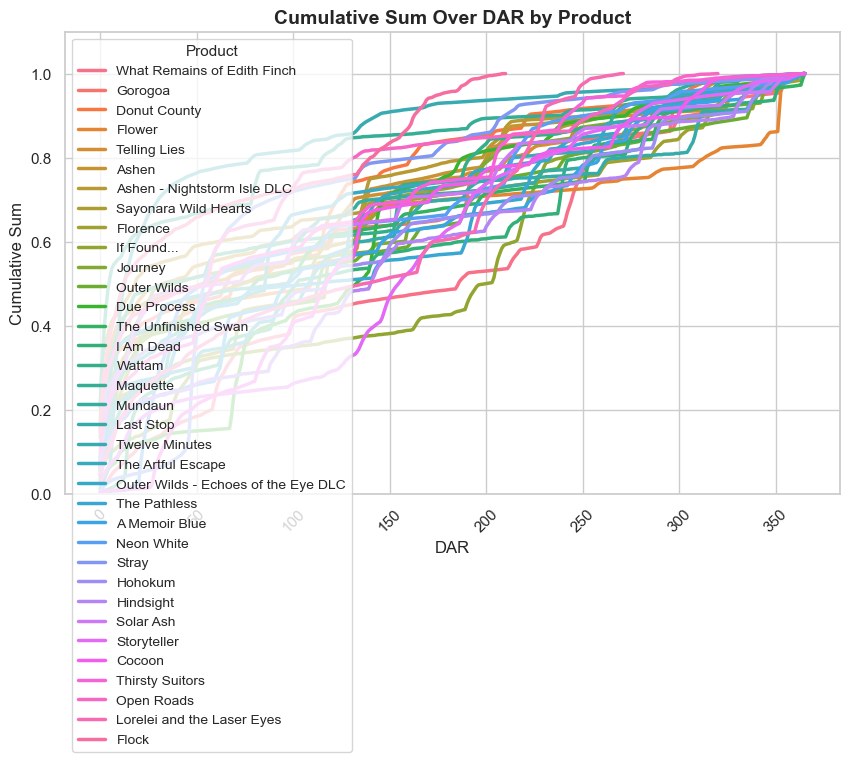

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=df_combined, x='DAR', y='prop_of_total', hue='product', linewidth=2.5)

# Improve labels and title
ax.set_xlabel("DAR", fontsize=12)
ax.set_ylabel("Cumulative Sum", fontsize=12)
ax.set_title("Cumulative Sum Over DAR by Product", fontsize=14, fontweight='bold')

# Improve legend
ax.legend(title="Product", fontsize=10, title_fontsize=11, loc="upper left", frameon=True)

# Rotate x-axis if needed
plt.xticks(rotation=45)
plt.ylim(0,1.1)

# Show plot
plt.show()

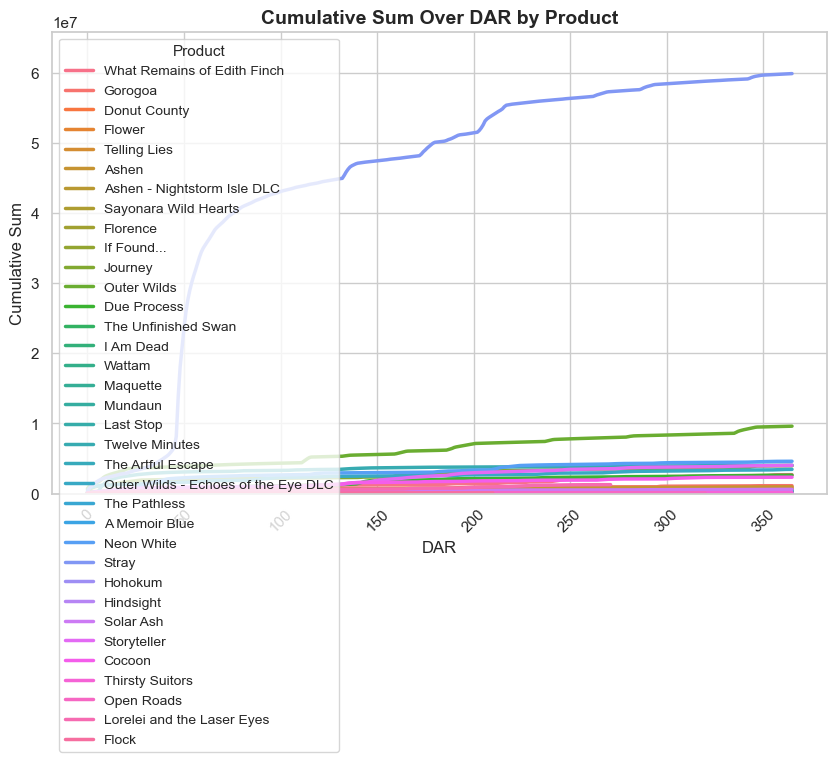

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=df_combined, x='DAR', y='Cumulative Selected Measure', hue='product', linewidth=2.5)

# Improve labels and title
ax.set_xlabel("DAR", fontsize=12)
ax.set_ylabel("Cumulative Sum", fontsize=12)
ax.set_title("Cumulative Sum Over DAR by Product", fontsize=14, fontweight='bold')

# Improve legend
ax.legend(title="Product", fontsize=10, title_fontsize=11, loc="upper left", frameon=True)

# Rotate x-axis if needed
plt.xticks(rotation=45)
plt.ylim(0,df_combined['Cumulative Selected Measure'].max()*1.1)

# Show plot
plt.show()

In [18]:
median_df = df_combined.groupby("DAR")[['Cumulative Selected Measure']].median()

In [19]:
median_df

,Cumulative Selected Measure
DAR,
0,18079.000
1,39980.370
2,56391.930
3,68891.310
4,79757.690
...,...
361,530891.935
362,531148.665
363,531409.210


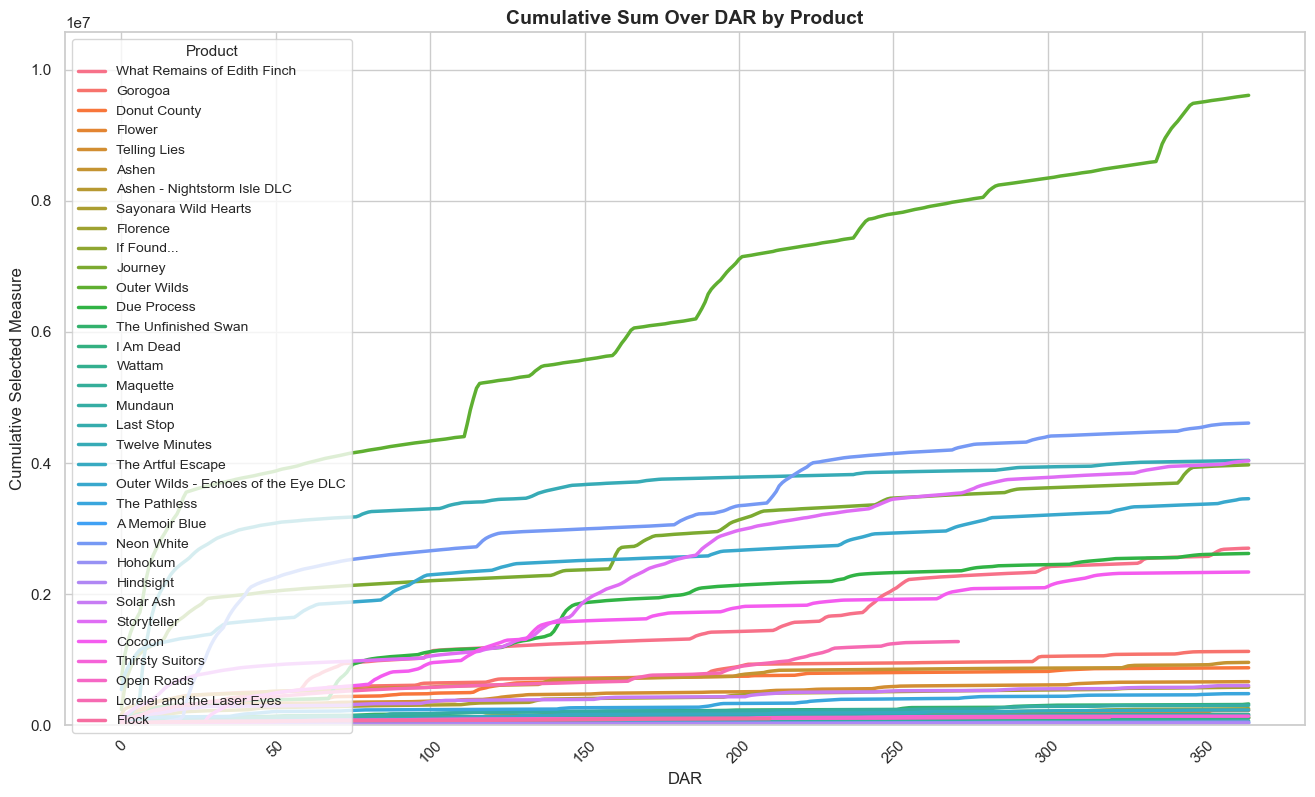

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(16, 9))
ax = sns.lineplot(data=title, x='DAR', y='Cumulative Selected Measure', hue='product', linewidth=2.5)

# Improve labels and title
ax.set_xlabel("DAR", fontsize=12)
ax.set_ylabel("Cumulative Selected Measure", fontsize=12)
ax.set_title("Cumulative Sum Over DAR by Product", fontsize=14, fontweight='bold')

# Improve legend
ax.legend(title="Product", fontsize=10, title_fontsize=11, loc="upper left", frameon=True)

# Rotate x-axis if needed
plt.xticks(rotation=45)

plt.ylim(0,title['Cumulative Selected Measure'].max()*1.1)
# Show plot
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


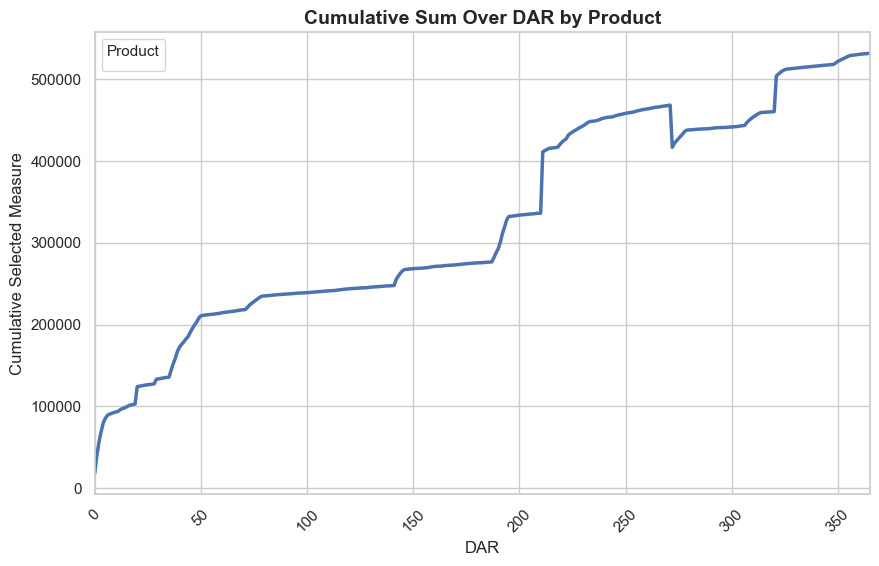

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=median_df, x='DAR', y='Cumulative Selected Measure', linewidth=2.5)

# Improve labels and title
ax.set_xlabel("DAR", fontsize=12)
ax.set_ylabel("Cumulative Selected Measure", fontsize=12)
ax.set_title("Cumulative Sum Over DAR by Product", fontsize=14, fontweight='bold')

# Improve legend
ax.legend(title="Product", fontsize=10, title_fontsize=11, loc="upper left", frameon=True)

# Rotate x-axis if needed
plt.xticks(rotation=45)

plt.xlim(0,365)
# Show plot
plt.show()

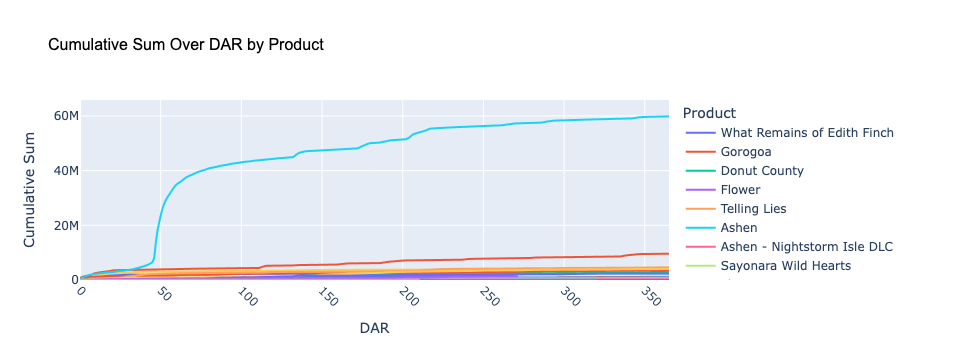

In [22]:
import plotly.express as px

# Create interactive plot
fig = px.line(
    df_combined,
    x="DAR",
    y="Cumulative Selected Measure",
    color="product",
    title="Cumulative Sum Over DAR by Product",
    labels={"DAR": "DAR", "Cumulative Sum": "Cumulative Sum", "product": "Product"},
    line_shape="linear"
)

# Improve layout
fig.update_layout(
    xaxis_title="DAR",
    yaxis_title="Cumulative Sum",
    title_font=dict(size=16, family="Arial", color="black"),
    legend_title_text="Product",
    xaxis=dict(tickangle=45, range=[0,365]),
    yaxis=dict(range=[0, df_combined["Cumulative Selected Measure"].max() * 1.1])
)

# Show interactive plot
fig.show()

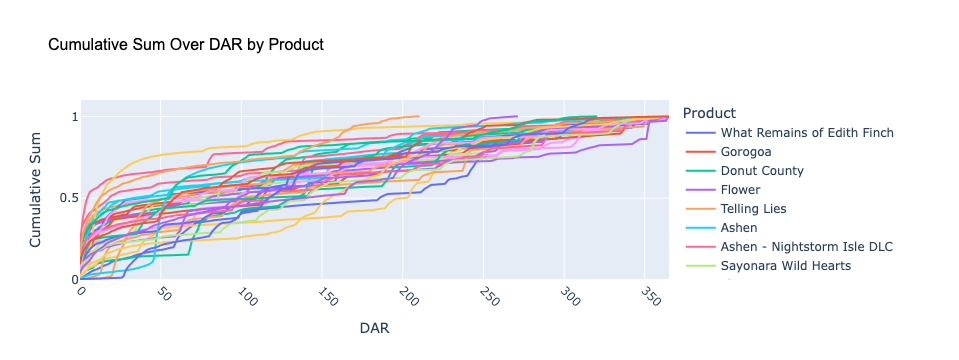

In [23]:
import plotly.express as px

# Create interactive plot
fig = px.line(
    df_combined,
    x="DAR",
    y="prop_of_total",
    color="product",
    title="Cumulative Sum Over DAR by Product",
    labels={"DAR": "DAR", "Cumulative Sum": "Cumulative Sum", "product": "Product"},
    line_shape="linear"
)

# Improve layout
fig.update_layout(
    xaxis_title="DAR",
    yaxis_title="Cumulative Sum",
    title_font=dict(size=16, family="Arial", color="black"),
    legend_title_text="Product",
    xaxis=dict(tickangle=45, range=[0,365]),
    yaxis=dict(range=[0, 1.1])
)

# Show interactive plot
fig.show()

## Functionitizing Charts

In [25]:
len(df_combined['product'].unique())

35

In [26]:
Title_Dict = {
    'What Remains of Edith Finch': 4,
    'Gorogoa': 1,
    'Donut County': 1,
    'Flower': 2,
    'Telling Lies': 1,
    'Ashen': 1,
    'Ashen - Nightstorm Isle DLC': 1,
    'Sayonara Wild Hearts': 1,
    'Florence': 1,
    'If Found...': 1,
    'Journey': 2,
    'Outer Wilds': 0,
    'Due Process': 1,
    'The Unfinished Swan': 1,
    'I Am Dead': 1,
    'Wattam': 1,
    'Maquette': 1,
    'Mundaun': 1,
    'Last Stop': 1,
    'Twelve Minutes': 1,
    'The Artful Escape': 1,
    'Outer Wilds - Echoes of the Eye DLC': 1,
    'The Pathless': 1,
    'A Memoir Blue': 1,
    'Neon White': 1,
    'Stray': 0,
    'Hohokum': 1,
    'Hindsight': 1,
    'Solar Ash': 1,
    'Storyteller': 1,
    'Cocoon': 1,
    'Thirsty Suitors': 1,
    'Open Roads': 1,
    'Lorelei and the Laser Eyes': 1,
    'Flock': 1
}

In [27]:
import plotly.express as px


def title_revenue_Curves(title_dict):
    df_combined['weight'] = df_combined['product'].map(title_dict)
    chart_df = df_combined.query("weight >=1")

    # Create interactive plot
    fig = px.line(
        chart_df,
        x="DAR",
        y="Cumulative Selected Measure",
        color="product",
        title="Cumulative Sum Over DAR by Product",
        labels={"DAR": "DAR", "Cumulative Sum": "Cumulative Sum", "product": "Product"},
        line_shape="linear"
    )
    
    # Improve layout
    fig.update_layout(
        xaxis_title="DAR",
        yaxis_title="Cumulative Sum",
        title_font=dict(size=16, family="Arial", color="black"),
        legend_title_text="Product",
        xaxis=dict(tickangle=45, range=[0,365]),
        yaxis=dict(range=[0, chart_df["Cumulative Selected Measure"].max() * 1.1])
    )
    fig.write_html("docs/CUME_Rev_by_product.html")
    # Show interactive plot
    fig.show()


    # Create interactive plot
    fig = px.line(
        chart_df,
        x="DAR",
        y="prop_of_total",
        color="product",
        title="Cumulative Sum Over DAR by Product",
        labels={"DAR": "DAR", "Cumulative Sum": "Cumulative Sum", "product": "Product"},
        line_shape="linear"
    )
    
    # Improve layout
    fig.update_layout(
        xaxis_title="DAR",
        yaxis_title="Cumulative Sum",
        title_font=dict(size=16, family="Arial", color="black"),
        legend_title_text="Product",
        xaxis=dict(tickangle=45, range=[0,365]),
        yaxis=dict(range=[0, 1.1])
    )
    fig.write_html("docs/PROP_Rev_by_product.html")
    # Show interactive plot
    fig.show()

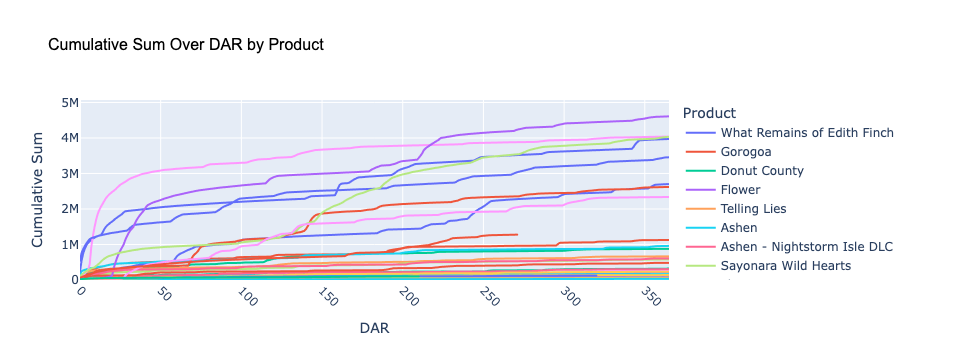

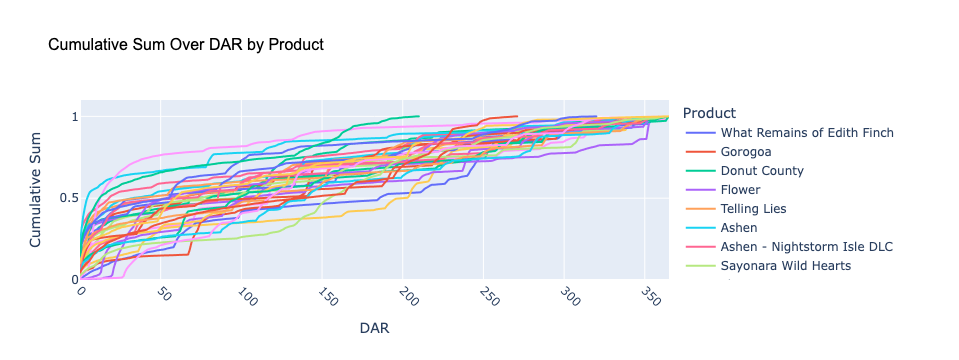

In [28]:
title_revenue_Curves(Title_Dict)

In [29]:
import plotly.express as px


def title_revenue_Curves_units(title_dict):
    df_combined['weight'] = df_combined['product'].map(title_dict)
    chart_df = df_combined.query("weight >=1")

    # Create interactive plot
    fig = px.line(
        chart_df,
        x="DAR",
        y="Cumulative Selected Measure",
        color="product",
        title="Cumulative Sum Over DAR by Product",
        labels={"DAR": "DAR", "Cumulative Sum": "Cumulative Sum", "product": "Product"},
        line_shape="linear"
    )
    
    # Improve layout
    fig.update_layout(
        xaxis_title="DAR",
        yaxis_title="Cumulative Sum",
        title_font=dict(size=16, family="Arial", color="black"),
        legend_title_text="Product",
        xaxis=dict(tickangle=45, range=[0,365]),
        yaxis=dict(range=[0, chart_df["Cumulative Selected Measure"].max() * 1.1])
    )
    fig.write_html("docs/CUME_Rev_by_product.html")
    # Show interactive plot
    fig.show()


    # Create interactive plot
    fig = px.line(
        chart_df,
        x="DAR",
        y="prop_of_total",
        color="product",
        title="Cumulative Sum Over DAR by Product",
        labels={"DAR": "DAR", "Cumulative Sum": "Cumulative Sum", "product": "Product"},
        line_shape="linear"
    )
    
    # Improve layout
    fig.update_layout(
        xaxis_title="DAR",
        yaxis_title="Cumulative Sum",
        title_font=dict(size=16, family="Arial", color="black"),
        legend_title_text="Product",
        xaxis=dict(tickangle=45, range=[0,365]),
        yaxis=dict(range=[0, 1.1])
    )
    fig.write_html("docs/PROP_Rev_by_product.html")
    # Show interactive plot
    fig.show()

In [30]:
df_combined.groupby("DAR")[["Cumulative Selected Measure", 'prop_of_total']].mean()


,Cumulative Selected Measure,prop_of_total
DAR,,
0,7.855909e+04,0.070381
1,1.360161e+05,0.116020
2,1.705124e+05,0.143195
3,1.976037e+05,0.163627
4,2.210323e+05,0.181458
...,...,...
361,3.271318e+06,0.996353
362,3.272748e+06,0.997032
363,3.273979e+06,0.997680


In [31]:
import plotly.express as px
import numpy as np

def combined_revenue_Curves(title_dict):
    df_combined['weight'] = df_combined['product'].map(title_dict).fillna(0)  # Default to 0 if not in dict
    
    # Filter products with weight >= 1
    chart_df = df_combined#.query("weight >= 1")

    # Compute weighted mean using the assigned weights
    chart_df = (
        chart_df
        .groupby("DAR")
        .apply(lambda g: 
            pd.Series({
                "Cumulative Selected Measure": np.average(g["Cumulative Selected Measure"], weights=g["weight"]),
                "prop_of_total": np.average(g["prop_of_total"], weights=g["weight"])
            })
        )
        .reset_index()
    )

    # Create interactive plot for Cumulative Selected Measure
    fig = px.line(
        chart_df,
        x="DAR",
        y="Cumulative Selected Measure",
        title="Cumulative Sum Over DAR by Product",
        labels={"DAR": "DAR", "Cumulative Selected Measure": "Cumulative Sum"},
        line_shape="linear"
    )
    
    # Improve layout
    fig.update_layout(
        xaxis_title="DAR",
        yaxis_title="Cumulative Sum",
        title_font=dict(size=16, family="Arial", color="black"),
        legend_title_text="Product",
        xaxis=dict(tickangle=45, range=[0,365]),
        yaxis=dict(range=[0, chart_df["Cumulative Selected Measure"].max() * 1.1])
    )
    
    fig.show()

    # Create interactive plot for prop_of_total
    fig = px.line(
        chart_df,
        x="DAR",
        y="prop_of_total",
        title="Proportion of Total Over DAR by Product",
        labels={"DAR": "DAR", "prop_of_total": "Proportion"},
        line_shape="linear"
    )
    
    fig.update_layout(
        xaxis_title="DAR",
        yaxis_title="Proportion",
        title_font=dict(size=16, family="Arial", color="black"),
        legend_title_text="Product",
        xaxis=dict(tickangle=45, range=[0,365]),
        yaxis=dict(range=[0, 1.1])
    )
    
    fig.show()
    return chart_df

/var/folders/vh/qvl8gx_d2m370qv72srt5r1m0000gp/T/ipykernel_7327/2035603541.py:14: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



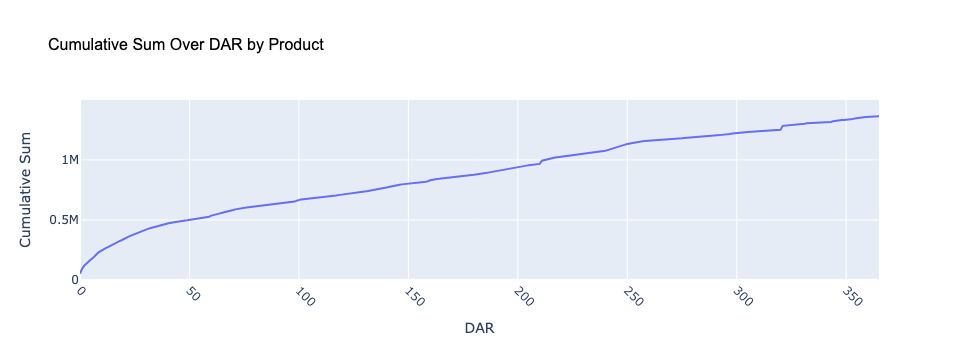

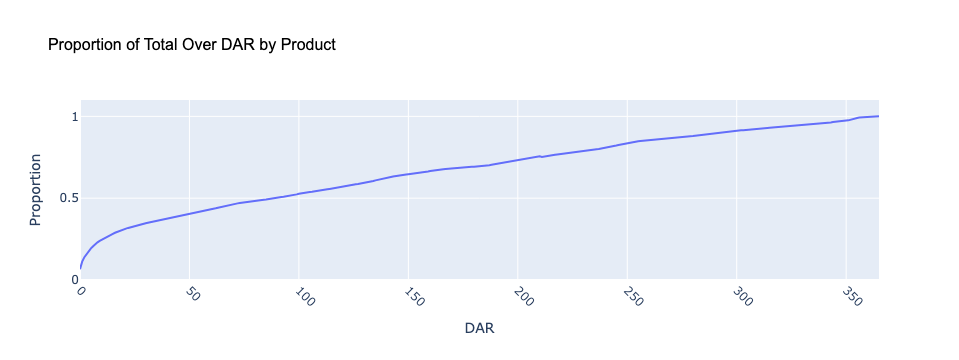

In [32]:
chart_df = combined_revenue_Curves(Title_Dict)

In [57]:
chart_df

,DAR,Cumulative Selected Measure,prop_of_total
0,0,5.308821e+04,0.066218
1,1,9.538852e+04,0.112094
2,2,1.209137e+05,0.139595
3,3,1.396950e+05,0.160151
4,4,1.568350e+05,0.178162
...,...,...,...
361,361,1.359437e+06,0.996404
362,362,1.360525e+06,0.997117
363,363,1.361362e+06,0.997781
364,364,1.362100e+06,0.998942


In [33]:
temp_table = chart_df.iloc[0::7]

In [34]:
temp_table.to_csv("steam.csv")

In [35]:
stop


NameError: name 'stop' is not defined

In [48]:
# Define folder path
folder_path = "/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/"

# Get all .xlsx files in the folder
files = glob.glob(f"{folder_path}/*.csv")

# Read all files into DataFrames and add filename column
csvs = [pd.read_csv(file).assign(Source=os.path.basename(file)) for file in files]

# Combine all DataFrames
df_combined = pd.concat(csvs, ignore_index=True)

In [49]:
df_combined

,Unnamed: 0,DAR,Cumulative Selected Measure,prop_of_total,Source
0,0,0,1.348268e+04,0.034283,ps.csv
1,7,7,5.929897e+04,0.146996,ps.csv
2,14,14,8.040648e+04,0.199761,ps.csv
3,21,21,1.038582e+05,0.239846,ps.csv
4,28,28,1.261630e+05,0.281667,ps.csv
...,...,...,...,...,...
207,336,336,1.307717e+06,0.953337,steam.csv
208,343,343,1.316529e+06,0.963059,steam.csv
209,350,350,1.334486e+06,0.974653,steam.csv
210,357,357,1.355192e+06,0.993654,steam.csv


In [53]:
import plotly.express as px
import numpy as np

def SKU_curves(df):
    
    # Filter products with weight >= 1
    chart_df = df

    # Create interactive plot for Cumulative Selected Measure
    fig = px.line(
        chart_df,
        x="DAR",
        y="Cumulative Selected Measure",
        color='Source',
        title="Cumulative Sum Over DAR by Product",
        labels={"DAR": "DAR", "Cumulative Selected Measure": "Cumulative Sum"},
        line_shape="linear"
    )
    
    # Improve layout
    fig.update_layout(
        xaxis_title="DAR",
        yaxis_title="Cumulative Sum",
        title_font=dict(size=16, family="Arial", color="black"),
        legend_title_text="Product",
        xaxis=dict(tickangle=45, range=[0,365]),
        yaxis=dict(range=[0, chart_df["Cumulative Selected Measure"].max() * 1.1])
    )
    fig.write_html("docs/SKU_CUME.html")
    fig.show()

    # Create interactive plot for prop_of_total
    fig = px.line(
        chart_df,
        x="DAR",
        y="prop_of_total",
        color ='Source',
        title="Proportion of Total Over DAR by Product",
        labels={"DAR": "DAR", "prop_of_total": "Proportion"},
        line_shape="linear"
    )
    
    fig.update_layout(
        xaxis_title="DAR",
        yaxis_title="Proportion",
        title_font=dict(size=16, family="Arial", color="black"),
        legend_title_text="Product",
        xaxis=dict(tickangle=45, range=[0,365]),
        yaxis=dict(range=[0, 1.1])
    )
    fig.write_html("docs/SKU_PROP.html")
    fig.show()


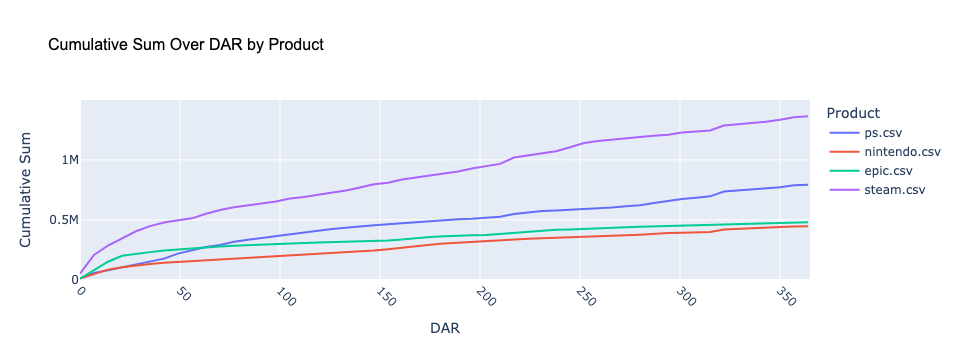

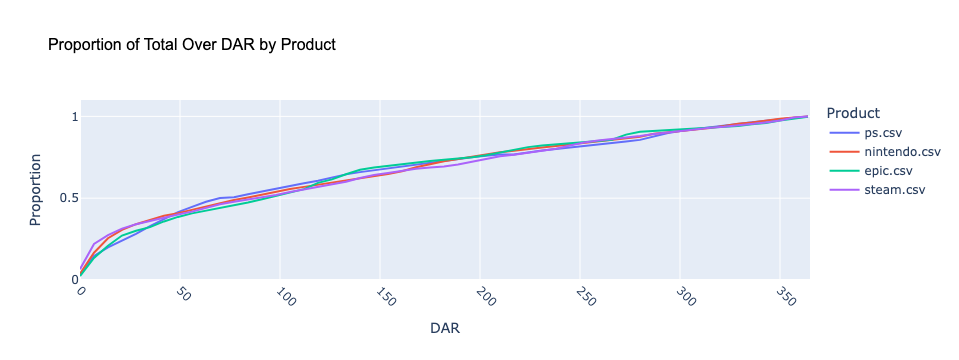

In [55]:
SKU_curves(df_combined)